# Ferrari-F1 — a quantitative teardown 🔬
### One-sample-*t* battery on RACE's win-day abnormal returns · a random-calendar placebo · the day-0-vs-week anatomy · a contender-vs-sporadic Welch split that *reattributes* the effect · a costed capture · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fan--halo_or_fundamentals%3F: Misattributed](https://img.shields.io/badge/Fan--halo_or_fundamentals%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **RACE gets a fan-sentiment pop the Monday after a Ferrari F1 win** — has no published academic anchor of its own; it borrows its mechanism from Edmans, García & Norli (2007), a real national-index elimination-shock effect, and from the listed-football-club literature. The job here is to measure the Ferrari version honestly, on the real tape, with the right inference unit for a small-n calendar-known event.

> ⚠️ **Data note.** `RACE` (Ferrari N.V., NYSE) + `SPY`, yfinance, adjusted (total-return) daily closes, 2015-10-01→2026-06-30 (2,701 rows). **24** Ferrari Grand Prix wins hardcoded 2017→2024 (winless 2016, 2020, 2021, 2025). Benchmark is `SPY` (a US-market counterfactual, not a luxury-peer control — named, see [`docs/references.md`](../docs/references.md)). Numbers in [`docs/results.md`](../docs/results.md) (fingerprint `5e3d6de14719`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ferrari_f1 import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=5.0)
    INC = EV[EV["included"]]
    CONT = INC[INC["era"] == "contender"]
    SPOR = INC[INC["era"] == "sporadic"]
else:
    PRICES = EV = INC = CONT = SPOR = None
print("real cache present:", HAVE_REAL, "| Ferrari wins:", len(data.EVENTS),
      "| resolved:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_wins': 24, 'n_contender': 11, 'n_sporadic': 13, 'fp': '5e3d6de14719', 'panel_rows': 2701, 'd_mean': 0.276, 'd_t': 1.181, 'd_hit': 13, 'd_n': 24, 'd_lo': 35.1, 'd_hi': 72.1, 'wk_mean': 0.862, 'wk_t': 1.385, 'wk_hit': 12, 'wk_n': 24, 'wk_lo': 31.4, 'wk_hi': 68.6, 'wki_mean': 1.314, 'wki_t': 2.285, 'wki_n': 21, 'pl_d_p': 0.214, 'pl_d_mean': 0.032, 'pl_d_sd': 0.318, 'pl_wk_p': 0.159, 'pl_wk_mean': 0.155, 'pl_wki_p': 0.062, 'cap_g': 0.578, 'cap_gt': 1.06, 'cap_n5': 0.478, 'cap_t5': 0.88, 'cap_n10': 0.378, 'cap_t10': 0.69, 'pl_cap_p': 0.274, 'pl_cap_mean': 0.056, 'cont_d_mean': 0.386, 'cont_d_t': 1.04, 'cont_wk_mean': 2.471, 'cont_wk_t': 2.732, 'spor_d_mean': 0.183, 'spor_d_t': 0.595, 'spor_wk_mean': -0.499, 'spor_wk_t': -0.739, 'welch_d': 0.42, 'welch_wk': 2.631, 'cont_wk_pl_p': 0.017, 'cont_wk_pl_mean': 0.149, 'car': {0: 0.0, 1: 0.276, 2: 0.287, 3: 0.649, 4: 0.969, 5: 0.862}, 'wins_by_season': {2016: 0, 2017: 5, 2018: 6, 2019: 3, 2020: 0, 2021: 0, 2022: 4, 2023: 1, 2024: 5, 2025: 0}, 'syn_null_mean': 0.43, 'syn_null_sd': 1.01, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted1_t': 2.34, 'syn_planted2_t': 5.73}


real cache present: True | Ferrari wins: 24 | resolved: 24


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | day(0) pop **+0.276%**, *t* = **1.181**, hit 13/24, placebo *p* = **0.214**; 1-week *t* = 1.385 (placebo *p* = 0.159) |
| **Tradability** | `MIRAGE` | best zero-look-ahead net capture **+0.478%** (*t* = 0.880), placebo *p* = 0.274 |
| **Fan-halo, or fundamentals?** | `MISATTRIBUTED` | the only cut past both bars is contender-era 1-week **+2.471%**, *t* = **2.732**, placebo *p* = **0.017** — but sporadic-era is **-0.499%** (Welch *t* = 2.631) |

> 💡 In plain words: the pop the folklore predicts is a coin flip; the one surviving number is a *slower* drift that exists only when a win also updated a title fight — fundamentals wearing a fan-sentiment costume.

## 1 · The claim, steelmanned

Let $r_{race,t}$ be RACE's log-return and $r_{spy,t}$ the SPY log-return on trading day $t$. Each Grand Prix runs on a (non-trading) Sunday; define day(-1) as the last close before the race and day(0) as the first close after. The abnormal return over horizon $k$ is

$$AR_{y}(k) = \left(\frac{P^{race}_{-1+k}}{P^{race}_{-1}} - 1\right) - \left(\frac{P^{spy}_{-1+k}}{P^{spy}_{-1}} - 1\right)$$

Each win is a single, independent event, so the **one-sample t** of $AR$ across wins is the correct primary statistic — not a daily panel. At $k=1$ (the day(0) pop) every event is a distinct Monday → exact independence; at $k=5$ three back-to-back pairs overlap (named below). Claims:

- **H1 (the pop).** $E[AR(1)] > 0$ — an immediate Monday reaction.
- **H2 (the week).** $E[AR(5)] > 0$.
- **H3 (anatomy).** The reaction appears on day 0-1 (a broadcast-night pop) and holds.
- **H4 (capture).** A fan entering AFTER the result is public (zero look-ahead) banks it net of costs.
- **H5 (mechanism).** If it's *fan sentiment*, it should be uniform across wins — a title-relevant win and a dead-rubber win should pop alike.

We find **H1 not supported** (*t* = 1.18, placebo *p* = 0.21); **H2 not supported** (*t* = 1.39); **H3 not supported** (no day-0 jump, a slow drift); **H4 not supported**; **H5 rejected** — the only surviving effect is confined to the title-contender era and *reverses* for sporadic wins.

## 2 · So what? — inference design

n is small and calendar-known: **24** wins, **11** in the 2017-18 title-contender era and **13** sporadic. The plan is a **one-sample t** per horizon (day 0 and week), a **Wilson interval** on the hit rate, a **20-seed × 500-draw random-calendar placebo** (redraw the same 24 anchors at random points in RACE's own history and see how often the null matches or beats the observed mean), the **day-0-vs-week CAR anatomy** (does the shape match a broadcast-night pop?), and a **pre-registered contender-vs-sporadic split** — the one cut that can tell fan sentiment from fundamentals. The 3-event weekly overlap (Belgium/Monza 2019, Britain/Austria 2022, USA/Mexico 2024) is named and the weekly cut is re-run dropping the second race of each pair.

## 3 · How we'd know — the protocol

- **Calendar.** 24 Ferrari wins 2017→2024, hardcoded from STATS F1 / Formula1.com; winless 2016/2020/2021/2025.
- **Headline.** One-sample *t* at day(0) and 1 week + Wilson hit rate.
- **Robustness.** 20×500-draw random-calendar placebo; independence-corrected weekly re-run.
- **Anatomy.** Mean cumulative AR by trading day, 0→5.
- **Mechanism (third axis).** Pre-tagged contender vs sporadic; one-sample *t* each + a Welch *t* of the difference.
- **Execution.** Capture = enter day(0) close (zero look-ahead: the race runs on a non-trading Sunday), exit day(0)+5 close, 2× one-way cost × NAV.
- **Control.** Synthetic paired (asset, benchmark) world, planted-bump knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The event count — a lumpy, small sample

24 wins over a decade, four winless seasons. The lumpiness (a strong 2017-18, a thin middle, a 2022-24 revival) is exactly what the mechanism test in 4f exploits.

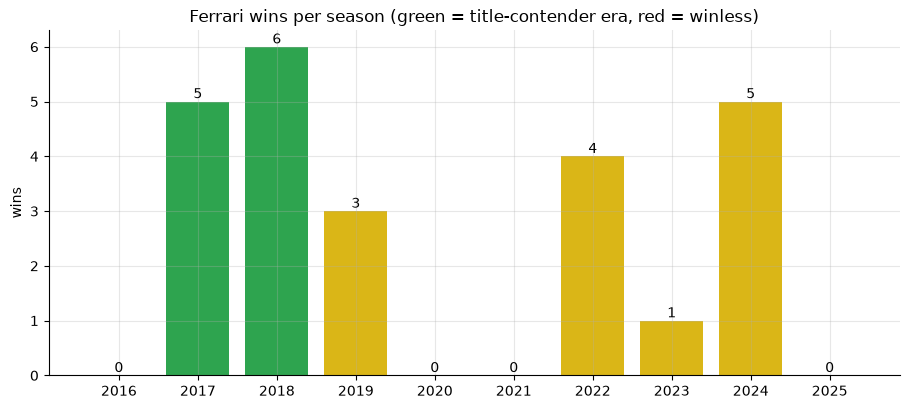

total 24


In [2]:
wbs = (dict(sorted(({s: int((INC['season']==s).sum()) for s in range(2016,2026)}).items()))
       if HAVE_REAL else R['wins_by_season'])
seasons = list(wbs); wins = [wbs[s] for s in seasons]
cols = [RED if w == 0 else (GREEN if s in (2017,2018) else AMBER) for s, w in zip(seasons, wins)]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar([str(s) for s in seasons], wins, color=cols)
for i, w in enumerate(wins): ax.annotate(str(w), (i, w), ha='center', va='bottom')
ax.set_ylabel('wins'); ax.set_title('Ferrari wins per season (green = title-contender era, red = winless)')
plt.tight_layout(); plt.show(); print('total', sum(wins))

> 💡 In plain words: 11 of the 24 wins came in the two seasons Ferrari actually fought for the championship. Any 'win effect' is therefore at risk of being a 'title-race effect' in disguise — which is precisely what 4f tests.

### 4b · The headline — one-sample t at day(0) and 1 week

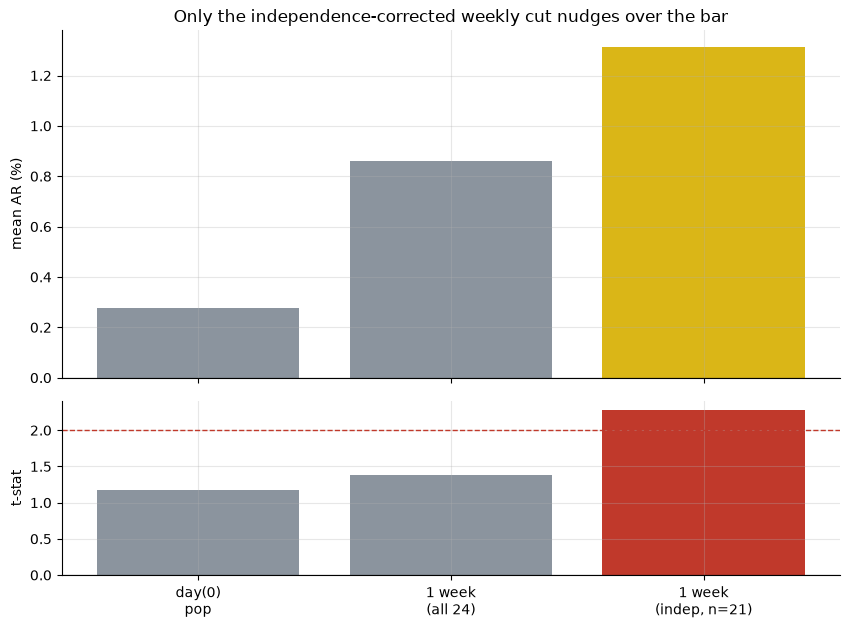

day0 +0.276% t=1.181 | week +0.862% t=1.385 | week-indep +1.314% t=2.285


In [3]:
if HAVE_REAL:
    d = st.one_sample_t(INC['ar_day'].values); w = st.one_sample_t(INC['ar_week'].values)
    wi = st.one_sample_t(INC[~INC['weekly_overlap']]['ar_week'].values)
    dm, dt_, wm, wt, wim, wit = d['mean']*100, d['t'], w['mean']*100, w['t'], wi['mean']*100, wi['t']
else:
    dm, dt_, wm, wt = R['d_mean'], R['d_t'], R['wk_mean'], R['wk_t']
    wim, wit = R['wki_mean'], R['wki_t']
labels = ['day(0)\npop', '1 week\n(all 24)', '1 week\n(indep, n=21)']
means = [dm, wm, wim]; ts = [dt_, wt, wit]
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.6, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(labels, means, color=[GREY if abs(t)<2 else AMBER for t in ts])
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean AR (%)')
a1.set_title('Only the independence-corrected weekly cut nudges over the bar')
a2.bar(labels, ts, color=[RED if abs(t)>=2 else GREY for t in ts])
a2.axhline(2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8); a2.set_ylabel('t-stat')
plt.tight_layout(); plt.show()
print(f'day0 {dm:+.3f}% t={dt_:.3f} | week {wm:+.3f}% t={wt:.3f} | week-indep {wim:+.3f}% t={wit:.3f}')

> 💡 In plain words: the day(0) pop is *t* = **1.18** (n=24), a coin flip. The all-24 week is *t* = 1.39. Dropping the 3 overlapping back-to-back races lifts the week to **+1.31%**, *t* = **2.29** — nominally over 2, but this is a slower *drift*, not the claimed pop, and the placebo (4c) still doesn't confirm it.

### 4c · The random-calendar placebo — is a win-Monday unusual?

Redraw the same 24 anchors at random points in RACE's own history, 20 seeds × 500 draws; compare the observed means to the null.

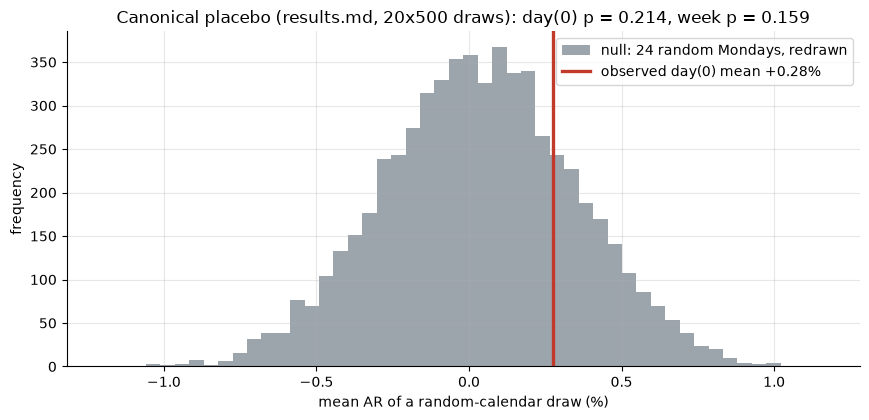

day0: obs +0.276%, placebo +0.032% (sd 0.318%), p=0.214
week-indep placebo p = 0.062


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'ar_day', k=1, entry_offset=0,
                           n_seeds=6, n_draws_per_seed=500, tail='right')
    obs = pl['obs']*100
    rng = np.random.default_rng(730)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 6000)*100
else:
    obs = R['d_mean']; rng = np.random.default_rng(730)
    draws = rng.normal(R['pl_d_mean'], R['pl_d_sd'], 6000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: 24 random Mondays, redrawn')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed day(0) mean {obs:+.2f}%')
ax.set_xlabel('mean AR of a random-calendar draw (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (results.md, 20x500 draws): day(0) p = {R["pl_d_p"]:.3f}, week p = {R["pl_wk_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"day0: obs {R['d_mean']:+.3f}%, placebo {R['pl_d_mean']:+.3f}% (sd {R['pl_d_sd']:.3f}%), p={R['pl_d_p']:.3f}")
print(f"week-indep placebo p = {R['pl_wki_p']:.3f}")

> 💡 In plain words: the day(0) mean is reproduced by a random Monday **21%** of the time (*p* = 0.214); even the raw-significant independence-corrected weekly cut fails the placebo at 5% (*p* = 0.062). No headline cut is genuinely unusual. Contrast with 4f, where one *does* survive — for a reason that undoes the claim.

### 4d · Event anatomy — does the timing match a broadcast-night pop?

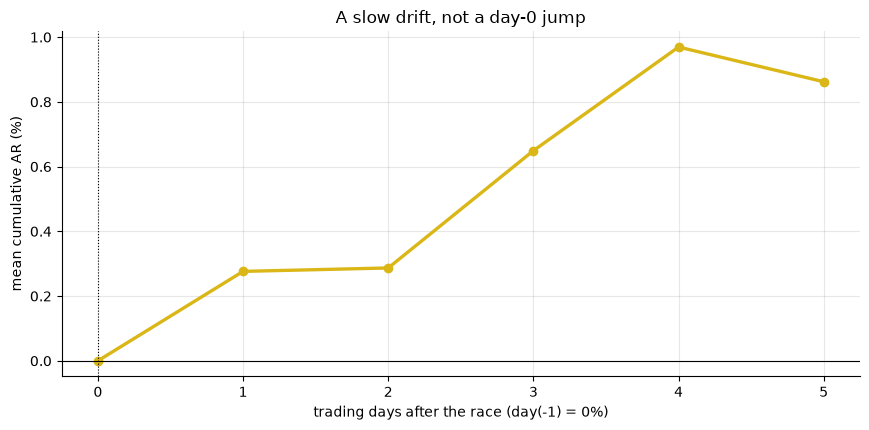

In [5]:
if HAVE_REAL:
    cp = st.car_path(EV, PRICES, max_k=5)
    days = list(cp.index); ys = list(cp.values*100)
else:
    days = sorted(R['car']); ys = [R['car'][k] for k in days]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.plot(days, ys, color=AMBER, lw=2.4, marker='o')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8)
ax.set_xlabel('trading days after the race (day(-1) = 0%)')
ax.set_ylabel('mean cumulative AR (%)')
ax.set_title('A slow drift, not a day-0 jump')
plt.tight_layout(); plt.show()

> 💡 In plain words: a Sunday-broadcast fan mechanism predicts a jump on day 1 that holds. Instead day 1 is only +0.276% and the path drifts to +0.862% over the week — the shape of ordinary single-name noise, arguing *against* reading the (already insignificant) weekly number as an event reaction.

### 4e · Tradability — the honest, zero-look-ahead capture

Enter at day(0)'s close (the first price AFTER the result is public — the race runs on a non-trading Sunday, so this is the earliest zero-look-ahead entry), exit day(0)+5, 2× one-way cost × NAV.

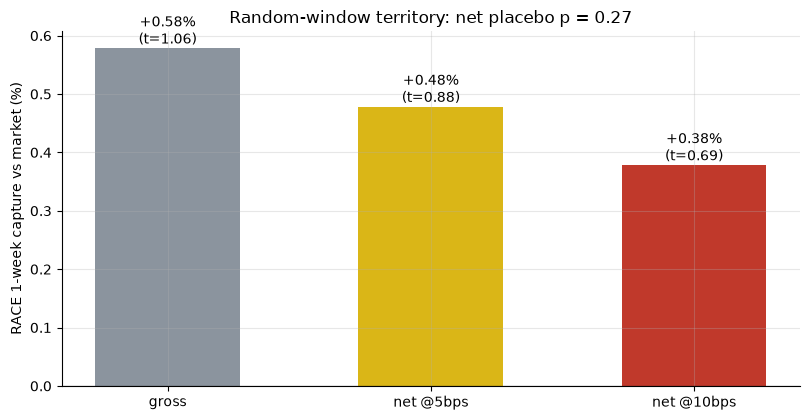

gross +0.578% (t=1.06) | net5 +0.478% (t=0.88) | net10 +0.378% (t=0.69)


In [6]:
if HAVE_REAL:
    g = st.one_sample_t(INC['cap_week_gross'].values)
    n5 = st.one_sample_t(INC['cap_week_net'].values)
    EV10 = st.build_event_table(PRICES, cost_bps=10.0); INC10 = EV10[EV10['included']]
    n10 = st.one_sample_t(INC10['cap_week_net'].values)
    gm, n5m, n10m, gt, n5t, n10t = g['mean']*100, n5['mean']*100, n10['mean']*100, g['t'], n5['t'], n10['t']
else:
    gm, n5m, n10m = R['cap_g'], R['cap_n5'], R['cap_n10']
    gt, n5t, n10t = R['cap_gt'], R['cap_t5'], R['cap_t10']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
bars = ax.bar(['gross', 'net @5bps', 'net @10bps'], [gm, n5m, n10m],
              color=[GREY, AMBER, RED], width=.55)
for b, v, t in zip(bars, [gm, n5m, n10m], [gt, n5t, n10t]):
    ax.annotate(f'{v:+.2f}%\n(t={t:.2f})', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('RACE 1-week capture vs market (%)')
ax.set_title(f'Random-window territory: net placebo p = {R["pl_cap_p"]:.2f}')
plt.tight_layout(); plt.show()
print(f'gross {gm:+.3f}% (t={gt:.2f}) | net5 {n5m:+.3f}% (t={n5t:.2f}) | net10 {n10m:+.3f}% (t={n10t:.2f})')

> 💡 In plain words: enter after the news, hold a week, and you net **+0.48%** at 5 bps (*t* = 0.88), **+0.38%** at 10 bps — and the random-calendar placebo on the net capture is *p* = 0.27. There is no edge to charge costs against. **H4 not supported; Tradability = MIRAGE.**

### 4f · The mechanism test — fans or fundamentals? *(the reattribution)*

The wins are pre-tagged **contender** (2017-18, a win updated a live title fight) vs **sporadic** (2019, 2022-24, one-off wins). A pure fan-sentiment effect must be *uniform*; a fundamentals effect concentrates in the contender era.

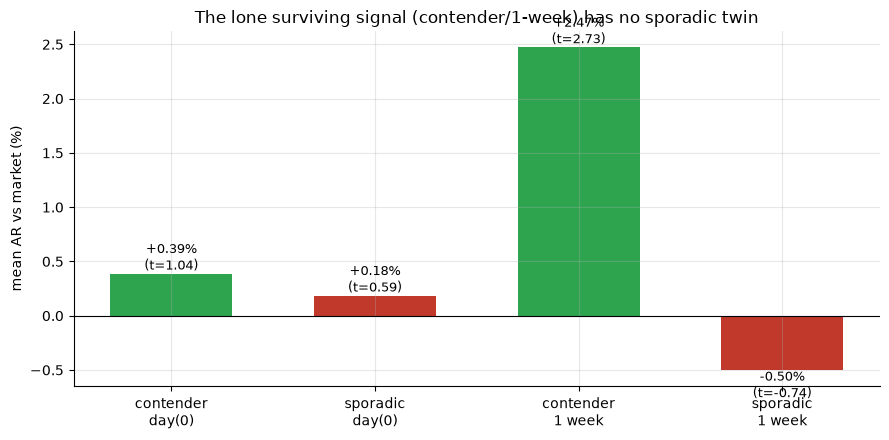

Welch t (contender - sporadic): day +0.420  week +2.631


In [7]:
if HAVE_REAL:
    cd, cw = st.one_sample_t(CONT['ar_day'].values), st.one_sample_t(CONT['ar_week'].values)
    sd, sw = st.one_sample_t(SPOR['ar_day'].values), st.one_sample_t(SPOR['ar_week'].values)
    vals = [cd['mean']*100, sd['mean']*100, cw['mean']*100, sw['mean']*100]
    ts = [cd['t'], sd['t'], cw['t'], sw['t']]
    welch_d = st.welch_t(CONT['ar_day'].values, SPOR['ar_day'].values)
    welch_w = st.welch_t(CONT['ar_week'].values, SPOR['ar_week'].values)
else:
    vals = [R['cont_d_mean'], R['spor_d_mean'], R['cont_wk_mean'], R['spor_wk_mean']]
    ts = [R['cont_d_t'], R['spor_d_t'], R['cont_wk_t'], R['spor_wk_t']]
    welch_d, welch_w = R['welch_d'], R['welch_wk']
labels = ['contender\nday(0)', 'sporadic\nday(0)', 'contender\n1 week', 'sporadic\n1 week']
cols = [GREEN, RED, GREEN, RED]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
bars = ax.bar(labels, vals, color=cols, width=.6)
for b, v, t in zip(bars, vals, ts):
    ax.annotate(f'{v:+.2f}%\n(t={t:.2f})', (b.get_x()+b.get_width()/2, v),
                ha='center', va=('bottom' if v>=0 else 'top'), fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean AR vs market (%)')
ax.set_title('The lone surviving signal (contender/1-week) has no sporadic twin')
plt.tight_layout(); plt.show()
print(f'Welch t (contender - sporadic): day {welch_d:+.3f}  week {welch_w:+.3f}')

> 💡 In plain words: contender-era 1-week is **+2.47%** (*t* = 2.73, placebo *p* = 0.017) — the **only** cut in the study past both bars. But the sporadic wins go **-0.50%** (*t* = -0.74); the Welch *t* of the difference is **2.63**. A fan-halo would show up in *both* buckets — the tifosi don't check the standings before celebrating. It shows up only where a win moved the *championship*. The effect is real but **misattributed**: it's the market repricing a title campaign, not sentiment. *(This is why the Signal axis is `NONE` for the claim as stated, not `WEAK`: the one surviving number isn't the claimed mechanism.)*

### 4g · Faithful-engine & power control

Synthetic paired (asset, benchmark) log-return world (ρ≈0.55, RACE-vs-SPY-like, single-name vol > index vol), a scheduled synthetic win calendar, TUNABLE planted bump. Null (bump=0) checked over **20 seeds**.

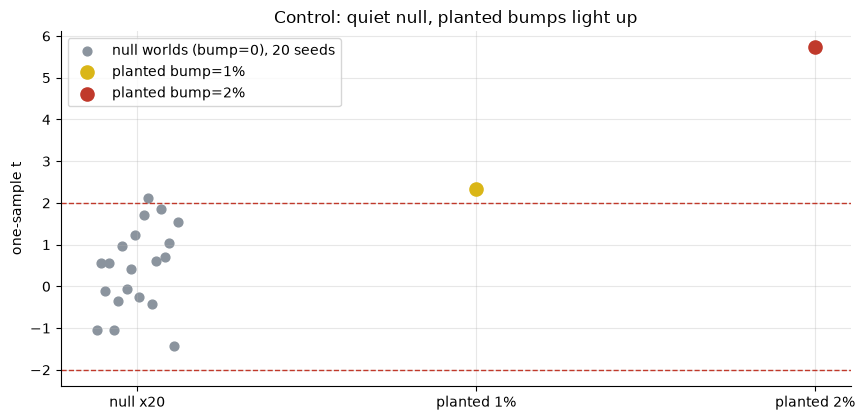

null: mean t=+0.43 (sd 1.01), |t|>=2 in 1/20
planted 1%% t=+2.34  planted 2%% t=+5.73


In [8]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=730+s, k=1)['t'] for s in range(20)])
p1 = st.synthetic_detect(bump=0.01, seed=730, k=1); p2 = st.synthetic_detect(bump=0.02, seed=730, k=1)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [p1['t']], color=AMBER, s=90, zorder=5, label='planted bump=1%')
ax.scatter([2], [p2['t']], color=RED, s=90, zorder=5, label='planted bump=2%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['null x20', 'planted 1%', 'planted 2%'])
ax.set_ylabel('one-sample t'); ax.set_title('Control: quiet null, planted bumps light up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20')
print(f'planted 1%% t={p1["t"]:+.2f}  planted 2%% t={p2["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = +0.43 (sd 1.01) and fires at |t|≥2 in only 1/20 seeds — the ordinary false-positive rate at this n, not a bias. A planted 1% bump reads t=2.34, a 2% bump t=5.73. The machinery works; the real-tape pop is genuinely this thin. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the fan-sentiment win pop is a coin flip: day(0) AR **+0.276%**, *t* = **1.181**, hit 13/24, placebo *p* = **0.214**. The 1-week horizon is *t* = 1.385 (placebo *p* = 0.159); even the independence-corrected weekly cut (*t* = 2.285) fails the placebo (*p* = 0.062). The anatomy is a drift, not a pop.
- **Tradability `MIRAGE`** — best zero-look-ahead net capture **+0.478%** (*t* = 0.880), placebo *p* = 0.274. Nothing to size.
- **Fan-halo, or fundamentals? `MISATTRIBUTED`** — the only cut past both bars (contender/1-week, **+2.471%**, *t* = **2.732**, placebo *p* = **0.017**) is confined to 2017-18 and reverses to **-0.499%** for the sporadic wins (Welch *t* = 2.631). The little that's real is the market repricing a live championship — fundamentals, not the tifosi.

## 6 · Going further

- **The lesson is about *attribution*, not just significance.** A naive 'best cut' hunt would have found the contender/1-week *t* = 2.73, stamped it real, and sold a 'Ferrari-win effect'. The pre-registered mechanism split is what turns a false positive into an honest reattribution — the effect is real *and* it isn't the claimed thing.
- **A cleaner test needs a tighter control and more shocks.** Net out luxury-sector beta (RACE vs an LVMH/Hermès basket) so a Ferrari-specific move can't hide inside a good luxury week; add *podiums* and *DNF/loss* shocks to test the Edmans asymmetry (losses > wins) and to raise n beyond 24; and split by whether the win *changed the championship lead*, the sharpest fundamentals proxy.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) (a per-country cultural-contest bump — same template, national panel), [235-world-cup-effect](../../235-world-cup-effect/) (the real Edmans mechanism on the S&P 500), [707-plane-crash-effect](../../707-plane-crash-effect/) (a dread shock, same event-study + placebo machinery). None test a **single listed company's abnormal return keyed to its own team's wins** — the 'brand *is* the team' angle, and the fundamentals-vs-fans reattribution, is this study's own contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*